In [2]:
import sys
sys.path.append("../src")

# Import preprocessing function
from preprocessing import preprocess_data

# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Train-Test Split
from sklearn.model_selection import train_test_split

# Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# TensorFlow Preprocessing
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# TensorFlow Models
from tensorflow.keras.models import Sequential

# ANN Layers
from tensorflow.keras.layers import (
    Embedding,
    Flatten,
    Dense,
    Dropout,
    LSTM
)

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# Load the preprocessed dataset
news_df = preprocess_data()

# Display first 5 rows
news_df.head()

,content,label
0,donald trump sends embarrassing new year’s eve...,0
1,drunk bragging trump staffer started russian c...,0
2,sheriff david clarke becomes internet joke thr...,0
3,trump obsessed even obama’s name coded website...,0
4,pope francis called donald trump christmas spe...,0


In [4]:
# Separate Features and Labels
X = news_df["content"]
y = news_df["label"]

print("Dataset Shape:", news_df.shape)
print("\nClass Distribution:")
print(news_df["label"].value_counts())

Dataset Shape: (44689, 2)

Class Distribution:
label
0    23478
1    21211
Name: count, dtype: int64


In [5]:
# Create Tokenizer
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size)

# Learn the vocabulary
tokenizer.fit_on_texts(X)

print("Tokenizer created successfully!")
print("Vocabulary Size:", len(tokenizer.word_index))

Tokenizer created successfully!
Vocabulary Size: 240703


In [6]:
# Convert text into sequences of integers
sequences = tokenizer.texts_to_sequences(X)

print("First Sequence:")
print(sequences[0])

print("\nTotal Articles:", len(sequences))

First Sequence:
[17, 2, 4411, 2523, 11, 3304, 4164, 415, 2640, 17, 2, 1741, 27, 1561, 11, 10, 554, 460, 213, 6085, 1426, 5987, 4412, 534, 32, 51, 39, 826, 106, 946, 9, 156, 24, 4226, 8900, 2718, 52, 1741, 459, 172, 1426, 5987, 44, 4412, 534, 32, 51, 1561, 3885, 11, 10, 6, 1435, 5385, 939, 1066, 275, 10, 87, 24, 4226, 8900, 2718, 52, 1741, 459, 172, 1426, 5987, 44, 4412, 534, 32, 51, 1561, 3885, 11, 10, 1066, 275, 10, 87, 17, 634, 2, 718, 526, 1757, 4760, 336, 287, 560, 6, 4411, 11, 10, 28, 6396, 5709, 2, 1044, 7113, 44, 523, 1167, 220, 378, 1741, 27, 354, 1561, 11, 10, 4659, 526, 1757, 9, 28, 526, 1757, 3008, 5, 38, 1066, 275, 10, 87, 12, 1266, 236, 121, 526, 1757, 1031, 150, 670, 49, 7, 552, 1745, 552, 5231, 526, 1757, 2109, 325, 5987, 11, 10, 1741, 526, 1757, 8845, 14, 1561, 11, 10, 526, 1757, 6106, 2, 11, 10, 4164, 336, 11, 10, 89, 49, 1426, 2056, 567, 3191, 65, 611, 17, 634, 2, 718, 526, 1757, 7832, 327, 11, 2, 2284, 415, 1426, 5987, 11, 10, 7226, 6457, 3826, 1963, 2965, 526, 1757,

In [7]:
# Pad all sequences to the same length

max_length = 300

X_padded = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Shape after Padding:", X_padded.shape)

print("\nLength of First Sequence:", len(X_padded[0]))

print("\nFirst 20 Tokens of First Sequence:")
print(X_padded[0][:20])

Shape after Padding: (44689, 300)

Length of First Sequence: 300

First 20 Tokens of First Sequence:
[  17    2 4411 2523   11 3304 4164  415 2640   17    2 1741   27 1561
   11   10  554  460  213 6085]


In [8]:
# Split the dataset into Training and Testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_padded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

print("\nTraining Labels Shape :", y_train.shape)
print("Testing Labels Shape  :", y_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

Training Data Shape : (35751, 300)
Testing Data Shape  : (8938, 300)

Training Labels Shape : (35751,)
Testing Labels Shape  : (8938,)

Training Class Distribution:
label
0    18782
1    16969
Name: count, dtype: int64

Testing Class Distribution:
label
0    4696
1    4242
Name: count, dtype: int64


In [9]:
# ---------------------------------
# Build ANN Model
# ---------------------------------

ann_model = Sequential()

# Embedding Layer
ann_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

# Flatten Layer
ann_model.add(Flatten())

# Hidden Layer
ann_model.add(Dense(128, activation="relu"))

# Dropout Layer
ann_model.add(Dropout(0.3))

# Output Layer
ann_model.add(Dense(1, activation="sigmoid"))

# Display Model Summary
ann_model.summary()

c:\Users\avani\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ---------------------------------
# Compile ANN Model
# ---------------------------------

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("ANN Model Compiled Successfully!")

ANN Model Compiled Successfully!


In [11]:
# ---------------------------------
# Create Early Stopping
# ---------------------------------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

# ---------------------------------
# Train ANN Model
# ---------------------------------

ann_history = ann_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 67s 146ms/step - accuracy: 0.9843 - loss: 0.0415 - val_accuracy: 0.9989 - val_loss: 0.0042
Epoch 2/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 53s 117ms/step - accuracy: 0.9997 - loss: 0.0014 - val_accuracy: 0.9986 - val_loss: 0.0066
Epoch 3/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.9999 - loss: 6.4302e-04 - val_accuracy: 0.9986 - val_loss: 0.0062


In [12]:
# ---------------------------------
# Evaluate ANN Model
# ---------------------------------

loss, accuracy = ann_model.evaluate(X_test, y_test)

print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9988 - loss: 0.0041

Test Loss     : 0.0041
Test Accuracy : 0.9988


In [13]:
# ---------------------------------
# ANN Predictions
# ---------------------------------

ann_predictions = ann_model.predict(X_test)

ann_predictions = (ann_predictions > 0.5).astype(int)

print("Prediction Shape:", ann_predictions.shape)

print("\nFirst 10 Predictions:")
print(ann_predictions[:10].flatten())

280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Prediction Shape: (8938, 1)

First 10 Predictions:
[1 1 1 0 1 0 0 0 0 1]


In [14]:
# ---------------------------------
# ANN Classification Report
# ---------------------------------

print("Classification Report - ANN Model\n")

print(classification_report(y_test, ann_predictions))

Classification Report - ANN Model

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



In [15]:
# ---------------------------------
# ANN Confusion Matrix
# ---------------------------------

ann_cm = confusion_matrix(y_test, ann_predictions)

print("Confusion Matrix - ANN Model\n")

print(ann_cm)

Confusion Matrix - ANN Model

[[4695    1]
 [  10 4232]]


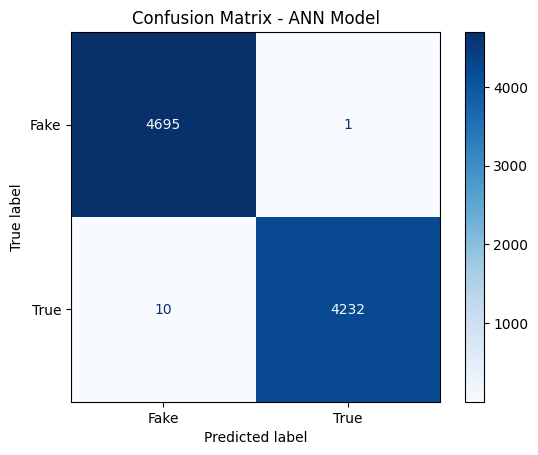

In [16]:
# ---------------------------------
# ANN Confusion Matrix Visualization
# ---------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=ann_cm,
    display_labels=["Fake", "True"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - ANN Model")

plt.show()

LSTM Model

In [17]:
# ---------------------------------
# Build LSTM Model
# ---------------------------------

lstm_model = Sequential()

# Embedding Layer
lstm_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    )
)

# LSTM Layer
lstm_model.add(
    LSTM(
        units=128
    )
)

# Dropout Layer
lstm_model.add(
    Dropout(0.3)
)

# Hidden Dense Layer
lstm_model.add(
    Dense(
        64,
        activation="relu"
    )
)

# Output Layer
lstm_model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

# Build Model
lstm_model.build(input_shape=(None, max_length))

# Display Summary
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,419,905 (5.42 MB)

 Trainable params: 1,419,905 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# ---------------------------------
# Compile LSTM Model
# ---------------------------------

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("LSTM Model Compiled Successfully!")

LSTM Model Compiled Successfully!


In [19]:
# ---------------------------------
# Create Early Stopping
# ---------------------------------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

# ---------------------------------
# Train LSTM Model
# ---------------------------------

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 179s 396ms/step - accuracy: 0.6162 - loss: 0.6215 - val_accuracy: 0.8979 - val_loss: 0.3302
Epoch 2/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 172s 385ms/step - accuracy: 0.8380 - loss: 0.4129 - val_accuracy: 0.9220 - val_loss: 0.2781
Epoch 3/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 166s 372ms/step - accuracy: 0.9277 - loss: 0.2264 - val_accuracy: 0.7999 - val_loss: 0.4345
Epoch 4/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 172s 384ms/step - accuracy: 0.8449 - loss: 0.3585 - val_accuracy: 0.9695 - val_loss: 0.1460
Epoch 5/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 170s 381ms/step - accuracy: 0.9825 - loss: 0.0662 - val_accuracy: 0.9952 - val_loss: 0.0198
Epoch 6/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 161s 361ms/step - accuracy: 0.9974 - loss: 0.0104 - val_accuracy: 0.9855 - val_loss: 0.0606
Epoch 7/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 162s 362ms/step - accuracy: 0.9992 - loss: 0.0034 - val_accuracy: 0.9966 - val_loss: 0.0162
Epoch 8/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 161s 359ms/step - accuracy: 0.9990 -

In [20]:
# ---------------------------------
# Evaluate LSTM Model
# ---------------------------------

loss, accuracy = lstm_model.evaluate(X_test, y_test)

print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - accuracy: 0.9981 - loss: 0.0080

Test Loss     : 0.0080
Test Accuracy : 0.9981


In [21]:
# ---------------------------------
# LSTM Predictions
# ---------------------------------

lstm_predictions = lstm_model.predict(X_test)

# Convert probabilities to class labels
lstm_predictions = (lstm_predictions > 0.5).astype(int)

print("Prediction Shape:", lstm_predictions.shape)

print("\nFirst 10 Predictions:")
print(lstm_predictions[:10].flatten())

280/280 ━━━━━━━━━━━━━━━━━━━━ 25s 88ms/step
Prediction Shape: (8938, 1)

First 10 Predictions:
[1 1 1 0 1 0 0 0 0 1]


In [22]:
# ---------------------------------
# LSTM Classification Report
# ---------------------------------

print("Classification Report - LSTM Model\n")

print(classification_report(y_test, lstm_predictions))

Classification Report - LSTM Model

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



In [23]:
# ---------------------------------
# LSTM Confusion Matrix
# ---------------------------------

lstm_cm = confusion_matrix(y_test, lstm_predictions)

print("Confusion Matrix - LSTM Model\n")

print(lstm_cm)

Confusion Matrix - LSTM Model

[[4685   11]
 [   6 4236]]


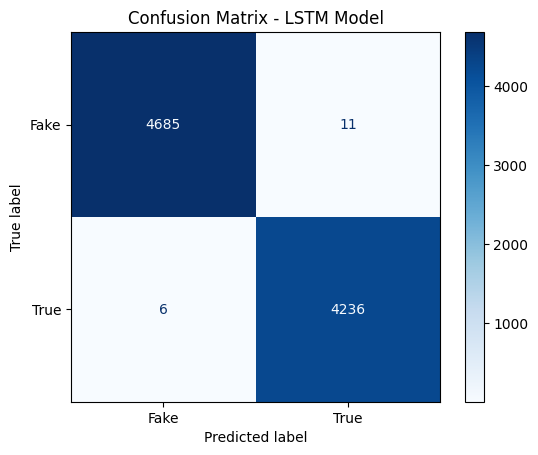

In [24]:
# ---------------------------------
# LSTM Confusion Matrix Visualization
# ---------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=lstm_cm,
    display_labels=["Fake", "True"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - LSTM Model")

plt.show()

In [27]:
ann_model.save("../models/best_ann_model.keras")

print("ANN Model Saved Successfully!")

ANN Model Saved Successfully!


In [25]:
# Save LSTM Model

lstm_model.save("../models/best_lstm_model.keras")

print("LSTM Model Saved Successfully!")

LSTM Model Saved Successfully!


In [26]:
import joblib

joblib.dump(tokenizer, "../models/tokenizer.pkl")

print("Tokenizer Saved Successfully!")

Tokenizer Saved Successfully!


In [1]:
from tensorflow.keras.models import load_model

loaded_model = load_model("../models/best_ann_model.keras")

loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 38400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,915,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,586,373 (70.90 MB)

 Trainable params: 6,195,457 (23.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,390,916 (47.27 MB)

In [3]:
import sys
sys.path.append("../src")

from text_cleaner import clean_text
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [4]:
sample_news = """
NASA announced that astronauts successfully completed a spacewalk
outside the International Space Station to upgrade its solar arrays.
"""

# Clean the text
cleaned = clean_text(sample_news)

print("Cleaned Text:")
print(cleaned)

# Convert to sequence
seq = tokenizer.texts_to_sequences([cleaned])

print("\nSequence Length:", len(seq[0]))
print("First 20 Tokens:", seq[0][:20])

# Pad sequence
pad = pad_sequences(
    seq,
    maxlen=300,
    padding="post",
    truncating="post"
)

# Predict using the ANN model
prob = ann_model.predict(pad, verbose=0)[0][0]

print("\nProbability:", prob)

Cleaned Text:
nasa announced astronaut successfully completed spacewalk outside international space station upgrade solar array


NameError: name 'tokenizer' is not defined

In [5]:
import joblib

tokenizer = joblib.load("../models/tokenizer.pkl")

print("Tokenizer loaded successfully!")

Tokenizer loaded successfully!


In [6]:
sample_news = """
NASA announced that astronauts successfully completed a spacewalk
outside the International Space Station to upgrade its solar arrays.
"""

# Clean the text
cleaned = clean_text(sample_news)

print("Cleaned Text:")
print(cleaned)

# Convert to sequence
seq = tokenizer.texts_to_sequences([cleaned])

print("\nSequence Length:", len(seq[0]))
print("First 20 Tokens:", seq[0][:20])

# Pad sequence
pad = pad_sequences(
    seq,
    maxlen=300,
    padding="post",
    truncating="post"
)

# Predict using the ANN model
prob = ann_model.predict(pad, verbose=0)[0][0]

print("\nProbability:", prob)

Cleaned Text:
nasa announced astronaut successfully completed spacewalk outside international space station upgrade solar array

Sequence Length: 11
First 20 Tokens: [7549, 503, 3473, 3455, 537, 216, 1775, 1267, 7066, 5736, 7160]


NameError: name 'ann_model' is not defined

In [7]:
from tensorflow.keras.models import load_model

ann_model = load_model("../models/best_ann_model.keras")

print("ANN Model Loaded Successfully!")

ANN Model Loaded Successfully!


In [8]:
import sys
sys.path.append("../src")

from text_cleaner import clean_text
from tensorflow.keras.preprocessing.sequence import pad_sequences

sample_news = """
NASA announced that astronauts successfully completed a spacewalk
outside the International Space Station to upgrade its solar arrays.
"""

cleaned = clean_text(sample_news)

seq = tokenizer.texts_to_sequences([cleaned])

pad = pad_sequences(
    seq,
    maxlen=300,
    padding="post",
    truncating="post"
)

prob = ann_model.predict(pad, verbose=0)[0][0]

print("Cleaned Text:", cleaned)
print("Sequence Length:", len(seq[0]))
print("Probability:", prob)

Cleaned Text: nasa announced astronaut successfully completed spacewalk outside international space station upgrade solar array
Sequence Length: 11
Probability: 5.2342682e-05
